# Task VI: Quantum Representation Learning


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Overview

This notebook implements a contrastive learning framework that uses **parameterized quantum circuits** to learn representations of classical image data. The key idea:

1. Encode classical images into quantum states via trainable quantum circuits
2. Use the **SWAP test** to measure fidelity (similarity) between quantum state representations
3. Train with a **contrastive loss** so that same-class images map to similar quantum states, while different-class images map to orthogonal states

### Architecture

![Architecture](assets/task_vi_architecture.png)

## 0. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import datasets, transforms

import pennylane as qml
from pennylane import numpy as pnp

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")

PennyLane version: 0.44.1
PyTorch version: 2.11.0


## 1. Data Loading and Preprocessing

I use a subset of MNIST (digits 0–3) and reduce dimensionality via PCA.

**Why PCA to 4 dimensions?** Each quantum feature is encoded on one qubit. With $n$ qubits one can represent $2^n$ amplitudes, but our angle-encoding scheme maps one classical feature per qubit via rotation gates. Using 4 qubits means I need exactly 4 classical features. PCA is a good fit here: it preserves the maximum variance in the fewest dimensions, giving the quantum circuit the most informative features to work with.

In [2]:
# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Filter to digits 0-3 only
CLASSES = [0, 1, 2, 3]
SAMPLES_PER_CLASS = 500
TEST_SAMPLES_PER_CLASS = 100

def filter_and_sample(dataset, classes, samples_per_class):
    """Filter dataset to selected classes and sample a fixed number per class."""
    images_by_class = defaultdict(list)
    for img, label in dataset:
        if label in classes:
            images_by_class[label].append(img.numpy().flatten())
    
    all_images, all_labels = [], []
    for cls in classes:
        imgs = np.array(images_by_class[cls][:samples_per_class])
        all_images.append(imgs)
        all_labels.extend([cls] * len(imgs))
    
    return np.vstack(all_images), np.array(all_labels)

X_train, y_train = filter_and_sample(mnist_train, CLASSES, SAMPLES_PER_CLASS)
X_test, y_test = filter_and_sample(mnist_test, CLASSES, TEST_SAMPLES_PER_CLASS)

print(f"Training set: {X_train.shape[0]} images, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} images")
print(f"Classes:      {CLASSES}")
print(f"Train label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 398kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.92MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.76MB/s]


Training set: 2000 images, 784 features
Test set:     400 images
Classes:      [0, 1, 2, 3]
Train label distribution: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500)}


In [3]:
# PCA: 784 → 4 dimensions
N_COMPONENTS = 4

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Scale to [0, 1] so rotation angles are in [0, π] after scaling by π
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_pca = scaler.fit_transform(X_train_pca)
X_test_pca = scaler.transform(X_test_pca)

explained_var = pca.explained_variance_ratio_
print(f"PCA: {X_train.shape[1]} → {N_COMPONENTS} dimensions")
print(f"Explained variance per component: {explained_var}")
print(f"Total explained variance: {explained_var.sum():.3f}")

PCA: 784 → 4 dimensions
Explained variance per component: [0.17580462 0.07929269 0.07111091 0.05861754]
Total explained variance: 0.385


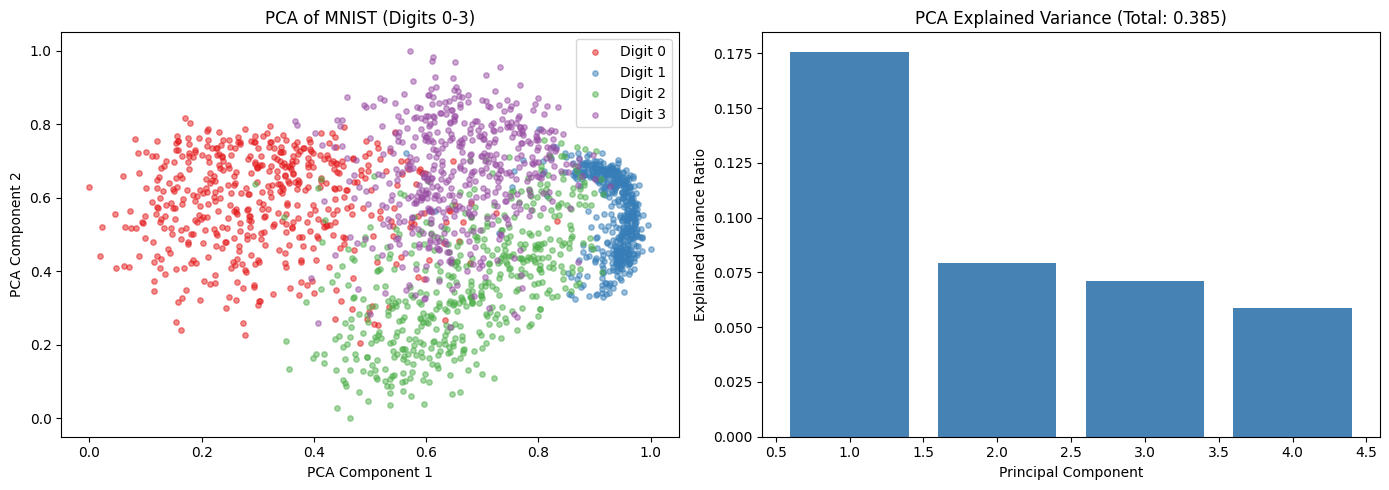

In [4]:
# Visualize: PCA components 1 vs 2, colored by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for cls, color in zip(CLASSES, colors):
    mask = y_train == cls
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=color, label=f'Digit {cls}', alpha=0.5, s=15)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title('PCA of MNIST (Digits 0-3)')
axes[0].legend()

axes[1].bar(range(1, N_COMPONENTS + 1), explained_var, color='steelblue')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title(f'PCA Explained Variance (Total: {explained_var.sum():.3f})')

plt.tight_layout()
plt.show()

## 2. Quantum State Preparation Function

I build a parameterized quantum circuit that encodes classical features into quantum states. The circuit has:

- **Feature encoding layer**: $R_Y(\text{feature}_i \cdot \pi \cdot s_i)$ on qubit $i$, where $s_i$ are trainable scaling parameters
- **Trainable layer 1**: $R_Y(\theta_i)$ rotations + CNOT entangling ring
- **Trainable layer 2**: $R_Z(\phi_i)$ rotations + CNOT entangling ring

The trainable parameters learn to map same-class images to similar quantum states and different-class images to orthogonal states.

In [5]:
N_QUBITS = 4  # Matches PCA components

# Parameter counts:
# - 4 scaling params for feature encoding
# - 4 RY params (layer 1)
# - 4 RZ params (layer 2)
# Total: 12 trainable parameters per state-prep block
N_PARAMS = 3 * N_QUBITS  # 12

def quantum_state_prep(image_features, params, wires):
    """Prepare a quantum state from classical image features.
    
    Args:
        image_features: array of shape (4,) — reduced MNIST features in [0, 1]
        params: trainable parameters of shape (12,)
            params[0:4]  — scaling factors for feature encoding
            params[4:8]  — RY rotation angles (trainable layer 1)
            params[8:12] — RZ rotation angles (trainable layer 2)
        wires: which qubits to act on (list of 4 wire indices)
    """
    n = len(wires)
    scales = params[0:n]
    ry_params = params[n:2*n]
    rz_params = params[2*n:3*n]
    
    # Feature encoding: RY(feature * π * scale)
    for i in range(n):
        qml.RY(image_features[i] * np.pi * scales[i], wires=wires[i])
    
    # Trainable layer 1: RY rotations + CNOT entanglement ring
    for i in range(n):
        qml.RY(ry_params[i], wires=wires[i])
    for i in range(n):
        qml.CNOT(wires=[wires[i], wires[(i + 1) % n]])
    
    # Trainable layer 2: RZ rotations + CNOT entanglement ring
    for i in range(n):
        qml.RZ(rz_params[i], wires=wires[i])
    for i in range(n):
        qml.CNOT(wires=[wires[i], wires[(i + 1) % n]])

print(f"State preparation uses {N_PARAMS} trainable parameters on {N_QUBITS} qubits")

State preparation uses 12 trainable parameters on 4 qubits


## 3. SWAP Test Circuit

The **SWAP test** is a fundamental quantum primitive for estimating the fidelity (overlap) between two quantum states $|\psi\rangle$ and $|\phi\rangle$ without full state tomography.

**Circuit:**
1. Prepare $|\psi\rangle$ on register A (qubits 0–3)
2. Prepare $|\phi\rangle$ on register B (qubits 4–7)
3. Initialize ancilla qubit (qubit 8) in $|0\rangle$, apply Hadamard
4. For each pair $(A_i, B_i)$: apply controlled-SWAP (CSWAP) conditioned on ancilla
5. Apply Hadamard on ancilla
6. Measure ancilla: $P(|0\rangle) = \frac{1 + |\langle\psi|\phi\rangle|^2}{2}$

From $P(|0\rangle)$ I extract the fidelity: $F = |\langle\psi|\phi\rangle|^2 = 2 P(|0\rangle) - 1$

In [6]:
# Total qubits: 4 (register A) + 4 (register B) + 1 (ancilla) = 9
N_TOTAL_QUBITS = 2 * N_QUBITS + 1  # 9
REGISTER_A = list(range(0, N_QUBITS))          # [0, 1, 2, 3]
REGISTER_B = list(range(N_QUBITS, 2*N_QUBITS)) # [4, 5, 6, 7]
ANCILLA = 2 * N_QUBITS                          # 8

dev = qml.device('default.qubit', wires=N_TOTAL_QUBITS)

@qml.qnode(dev, interface='torch', diff_method='parameter-shift')
def swap_test_circuit(features_a, features_b, params):
    """SWAP test circuit measuring fidelity between quantum encodings of two images.
    
    Args:
        features_a: PCA features of image A, shape (4,)
        features_b: PCA features of image B, shape (4,)
        params: trainable parameters, shape (12,) — shared between both encodings
    
    Returns:
        Expectation value of Pauli-Z on ancilla qubit.
        <Z> = 2*P(0) - 1 = |<ψ|φ>|², which IS the fidelity directly.
    """
    # Encode image A into register A
    quantum_state_prep(features_a, params, wires=REGISTER_A)
    
    # Encode image B into register B
    quantum_state_prep(features_b, params, wires=REGISTER_B)
    
    # SWAP test
    qml.Hadamard(wires=ANCILLA)
    
    for i in range(N_QUBITS):
        qml.CSWAP(wires=[ANCILLA, REGISTER_A[i], REGISTER_B[i]])
    
    qml.Hadamard(wires=ANCILLA)
    
    # <Z> on ancilla = |<ψ|φ>|²
    return qml.expval(qml.PauliZ(ANCILLA))

print(f"SWAP test circuit: {N_TOTAL_QUBITS} qubits (registers A={REGISTER_A}, B={REGISTER_B}, ancilla={ANCILLA})")

SWAP test circuit: 9 qubits (registers A=[0, 1, 2, 3], B=[4, 5, 6, 7], ancilla=8)


In [7]:
# Visualize the circuit with sample inputs
sample_a = torch.tensor(X_train_pca[0], dtype=torch.float64)
sample_b = torch.tensor(X_train_pca[1], dtype=torch.float64)
sample_params = torch.tensor(np.random.uniform(0, np.pi, N_PARAMS), dtype=torch.float64)

print("SWAP Test Circuit Structure:")
print("=" * 60)
print(qml.draw(swap_test_circuit, level='device')(
    sample_a, sample_b, sample_params
))

SWAP Test Circuit Structure:
0: ──RY(1.09)──RY(2.26)─╭●───────╭X──RZ(1.62)─╭●───────╭X─╭SWAP──────────────────────┤     
1: ──RY(0.87)──RY(2.21)─╰X─╭●────│───RZ(2.17)─╰X─╭●────│──│─────╭SWAP────────────────┤     
2: ──RY(0.20)──RY(1.42)────╰X─╭●─│───RZ(0.15)────╰X─╭●─│──│─────│─────╭SWAP──────────┤     
3: ──RY(1.19)──RY(1.64)───────╰X─╰●──RZ(2.23)───────╰X─╰●─│─────│─────│─────╭SWAP────┤     
4: ──RY(1.07)──RY(2.26)─╭●───────╭X──RZ(1.62)─╭●───────╭X─├SWAP─│─────│─────│────────┤     
5: ──RY(0.90)──RY(2.21)─╰X─╭●────│───RZ(2.17)─╰X─╭●────│──│─────├SWAP─│─────│────────┤     
6: ──RY(0.18)──RY(1.42)────╰X─╭●─│───RZ(0.15)────╰X─╭●─│──│─────│─────├SWAP─│────────┤     
7: ──RY(1.22)──RY(1.64)───────╰X─╰●──RZ(2.23)───────╰X─╰●─│─────│─────│─────├SWAP────┤     
8: ──H────────────────────────────────────────────────────╰●────╰●────╰●────╰●─────H─┤  <Z>


In [8]:
# Sanity check: identical inputs should give fidelity ≈ 1
fidelity_same = swap_test_circuit(sample_a, sample_a, sample_params)
fidelity_diff = swap_test_circuit(sample_a, sample_b, sample_params)

print(f"Fidelity (same image):      {fidelity_same.item():.6f}  (expected ≈ 1.0)")
print(f"Fidelity (different images): {fidelity_diff.item():.6f}")

Fidelity (same image):      1.000000  (expected ≈ 1.0)
Fidelity (different images): 0.999520


## 4. Contrastive Loss and Training

### Contrastive Loss Function

Given a pair of images with fidelity $F$ and label $y$ (1 = same class, 0 = different class):

$$\mathcal{L} = y \cdot (1 - F) + (1 - y) \cdot \max(0, F - m)$$

- **Same class ($y=1$)**: loss $= 1 - F$ — pushes fidelity toward 1
- **Different class ($y=0$)**: loss $= \max(0, F - m)$ — pushes fidelity below margin $m$

The margin $m$ prevents the model from wasting capacity pushing already-separated states further apart.

In [9]:
def contrastive_loss(fidelity, same_class, margin=0.2):
    """Contrastive loss for quantum state fidelities.
    
    Args:
        fidelity: estimated fidelity from SWAP test
        same_class: 1.0 if same class, 0.0 if different class
        margin: margin for different-class pairs
    
    Returns:
        Scalar loss value
    """
    loss_same = same_class * (1.0 - fidelity)
    loss_diff = (1.0 - same_class) * torch.clamp(fidelity - margin, min=0.0)
    return loss_same + loss_diff

In [10]:
def generate_pairs(X, y, batch_size=16):
    """Generate balanced pairs: 50% same-class, 50% different-class.
    
    Returns:
        features_a: (batch_size, 4)
        features_b: (batch_size, 4)
        labels: (batch_size,) — 1.0 for same class, 0.0 for different
    """
    n = len(y)
    n_same = batch_size // 2
    n_diff = batch_size - n_same
    
    features_a, features_b, labels = [], [], []
    
    # Same-class pairs
    for _ in range(n_same):
        cls = np.random.choice(np.unique(y))
        idxs = np.where(y == cls)[0]
        i, j = np.random.choice(idxs, size=2, replace=False)
        features_a.append(X[i])
        features_b.append(X[j])
        labels.append(1.0)
    
    # Different-class pairs
    for _ in range(n_diff):
        cls1, cls2 = np.random.choice(np.unique(y), size=2, replace=False)
        i = np.random.choice(np.where(y == cls1)[0])
        j = np.random.choice(np.where(y == cls2)[0])
        features_a.append(X[i])
        features_b.append(X[j])
        labels.append(0.0)
    
    return (
        torch.tensor(np.array(features_a), dtype=torch.float64),
        torch.tensor(np.array(features_b), dtype=torch.float64),
        torch.tensor(labels, dtype=torch.float64)
    )

In [11]:
# Training configuration
N_ITERATIONS = 80
BATCH_SIZE = 12
LEARNING_RATE = 0.1
MARGIN = 0.2

# Initialize trainable parameters
params = torch.tensor(
    np.concatenate([
        np.ones(N_QUBITS),                           # scaling factors (init to 1)
        np.random.uniform(0, 0.5, N_QUBITS),         # RY layer
        np.random.uniform(0, 0.5, N_QUBITS),         # RZ layer
    ]),
    dtype=torch.float64,
    requires_grad=True
)

optimizer = torch.optim.Adam([params], lr=LEARNING_RATE)

print(f"Training config:")
print(f"  Iterations:     {N_ITERATIONS}")
print(f"  Batch size:     {BATCH_SIZE} pairs")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Margin:         {MARGIN}")
print(f"  Parameters:     {len(params)} trainable")

Training config:
  Iterations:     80
  Batch size:     12 pairs
  Learning rate:  0.1
  Margin:         0.2
  Parameters:     12 trainable


In [12]:
# Training loop
history = {
    'loss': [],
    'avg_fidelity_same': [],
    'avg_fidelity_diff': []
}

print(f"{'Iter':>4s} | {'Loss':>8s} | {'F(same)':>8s} | {'F(diff)':>8s} | {'Gap':>8s}")
print("-" * 50)

for iteration in range(N_ITERATIONS):
    # Generate batch of pairs
    feat_a, feat_b, pair_labels = generate_pairs(X_train_pca, y_train, BATCH_SIZE)
    
    optimizer.zero_grad()
    
    # Forward pass: compute fidelity for each pair
    batch_loss = torch.tensor(0.0, dtype=torch.float64)
    fidelities_same, fidelities_diff = [], []
    
    for k in range(BATCH_SIZE):
        fidelity = swap_test_circuit(feat_a[k], feat_b[k], params)
        loss = contrastive_loss(fidelity, pair_labels[k], margin=MARGIN)
        batch_loss = batch_loss + loss
        
        if pair_labels[k] == 1.0:
            fidelities_same.append(fidelity.item())
        else:
            fidelities_diff.append(fidelity.item())
    
    batch_loss = batch_loss / BATCH_SIZE
    
    # Backward pass
    batch_loss.backward()
    optimizer.step()
    
    # Record metrics
    avg_f_same = np.mean(fidelities_same) if fidelities_same else 0.0
    avg_f_diff = np.mean(fidelities_diff) if fidelities_diff else 0.0
    history['loss'].append(batch_loss.item())
    history['avg_fidelity_same'].append(avg_f_same)
    history['avg_fidelity_diff'].append(avg_f_diff)
    
    if iteration % 5 == 0 or iteration == N_ITERATIONS - 1:
        gap = avg_f_same - avg_f_diff
        print(f"{iteration:4d} | {batch_loss.item():8.4f} | {avg_f_same:8.4f} | {avg_f_diff:8.4f} | {gap:+8.4f}")

print("\nTraining complete!")

Iter |     Loss |  F(same) |  F(diff) |      Gap
--------------------------------------------------


KeyboardInterrupt: 

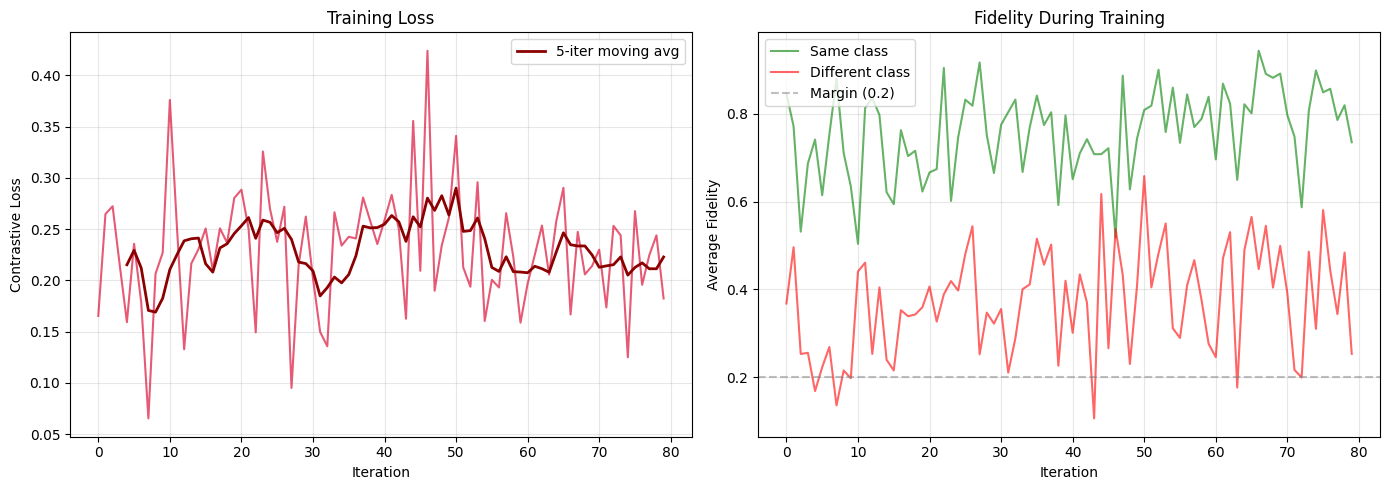

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['loss'], color='crimson', alpha=0.7)
# Smoothed
window = 5
if len(history['loss']) >= window:
    smoothed = np.convolve(history['loss'], np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(history['loss'])), smoothed, 
                 color='darkred', linewidth=2, label=f'{window}-iter moving avg')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Contrastive Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fidelity curves
axes[1].plot(history['avg_fidelity_same'], color='green', alpha=0.6, label='Same class')
axes[1].plot(history['avg_fidelity_diff'], color='red', alpha=0.6, label='Different class')
axes[1].axhline(y=MARGIN, color='gray', linestyle='--', alpha=0.5, label=f'Margin ({MARGIN})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Average Fidelity')
axes[1].set_title('Fidelity During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluation

I evaluate the trained model by computing pairwise fidelities on a held-out test set and examining the separation between same-class and different-class distributions.

In [ ]:
# Compute fidelities on test set pairs
N_EVAL_PAIRS = 200  # 100 same + 100 different

eval_feat_a, eval_feat_b, eval_labels = generate_pairs(
    X_test_pca, y_test, N_EVAL_PAIRS
)

eval_fidelities_same = []
eval_fidelities_diff = []

print(f"Evaluating {N_EVAL_PAIRS} test pairs...")
with torch.no_grad():
    for k in range(N_EVAL_PAIRS):
        fid = swap_test_circuit(eval_feat_a[k], eval_feat_b[k], params).item()
        if eval_labels[k] == 1.0:
            eval_fidelities_same.append(fid)
        else:
            eval_fidelities_diff.append(fid)
        
        if (k + 1) % 50 == 0:
            print(f"  {k+1}/{N_EVAL_PAIRS} pairs computed")

print(f"\nResults on test set:")
print(f"  Same-class fidelity:  mean={np.mean(eval_fidelities_same):.4f}, std={np.std(eval_fidelities_same):.4f}")
print(f"  Diff-class fidelity:  mean={np.mean(eval_fidelities_diff):.4f}, std={np.std(eval_fidelities_diff):.4f}")
print(f"  Separation gap:       {np.mean(eval_fidelities_same) - np.mean(eval_fidelities_diff):.4f}")

Evaluating 200 test pairs...
  50/200 pairs computed
  100/200 pairs computed
  150/200 pairs computed
  200/200 pairs computed

Results on test set:
  Same-class fidelity:  mean=0.7913, std=0.2364
  Diff-class fidelity:  mean=0.4068, std=0.2884
  Separation gap:       0.3845


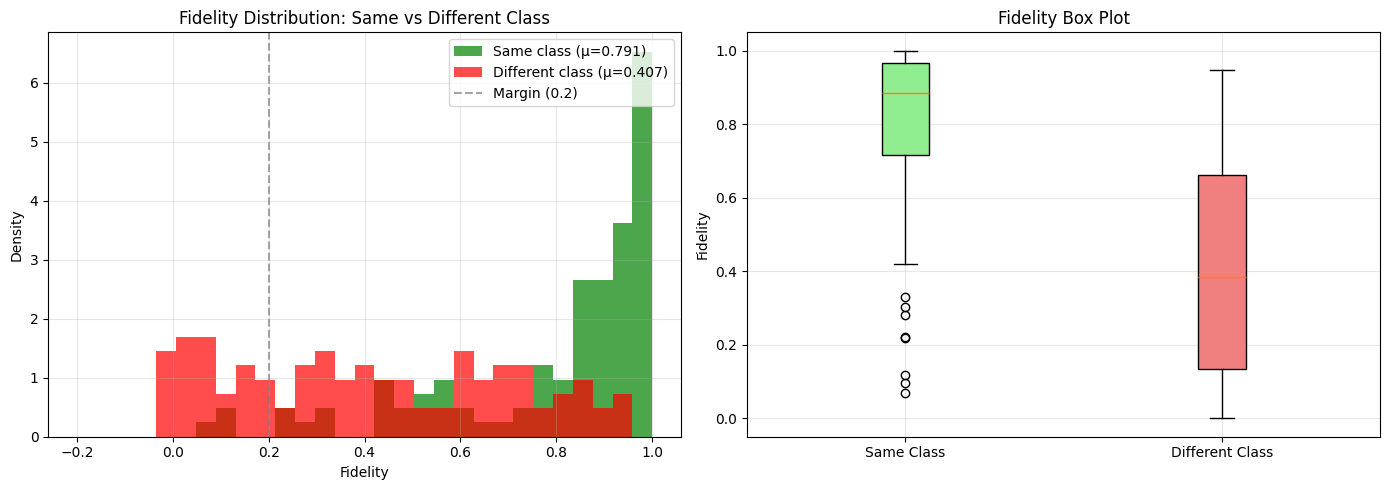

In [ ]:
# Fidelity distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
bins = np.linspace(-0.2, 1.0, 30)
axes[0].hist(eval_fidelities_same, bins=bins, alpha=0.7, color='green', 
             label=f'Same class (μ={np.mean(eval_fidelities_same):.3f})', density=True)
axes[0].hist(eval_fidelities_diff, bins=bins, alpha=0.7, color='red', 
             label=f'Different class (μ={np.mean(eval_fidelities_diff):.3f})', density=True)
axes[0].axvline(x=MARGIN, color='gray', linestyle='--', alpha=0.7, label=f'Margin ({MARGIN})')
axes[0].set_xlabel('Fidelity')
axes[0].set_ylabel('Density')
axes[0].set_title('Fidelity Distribution: Same vs Different Class')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
bp = axes[1].boxplot(
    [eval_fidelities_same, eval_fidelities_diff],
    labels=['Same Class', 'Different Class'],
    patch_artist=True
)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Fidelity')
axes[1].set_title('Fidelity Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# k-NN classification using fidelity as similarity metric
# For each test image, find the k nearest training images by fidelity

K = 5  # number of neighbors
N_TRAIN_REF = 80  # reference training images (20 per class)
N_TEST_EVAL = 40  # test images to classify (10 per class)

# Select balanced reference set
ref_indices = []
for cls in CLASSES:
    cls_idx = np.where(y_train == cls)[0][:N_TRAIN_REF // len(CLASSES)]
    ref_indices.extend(cls_idx)
ref_indices = np.array(ref_indices)

X_ref = torch.tensor(X_train_pca[ref_indices], dtype=torch.float64)
y_ref = y_train[ref_indices]

# Select balanced test set
test_indices = []
for cls in CLASSES:
    cls_idx = np.where(y_test == cls)[0][:N_TEST_EVAL // len(CLASSES)]
    test_indices.extend(cls_idx)
test_indices = np.array(test_indices)

X_eval = torch.tensor(X_test_pca[test_indices], dtype=torch.float64)
y_eval = y_test[test_indices]

print(f"k-NN Classification (k={K})")
print(f"  Reference set: {len(ref_indices)} images")
print(f"  Test set:      {len(test_indices)} images")
print(f"  Computing {len(test_indices) * len(ref_indices)} fidelities...")

correct = 0
predictions = []

with torch.no_grad():
    for i in range(len(test_indices)):
        fidelities = []
        for j in range(len(ref_indices)):
            fid = swap_test_circuit(X_eval[i], X_ref[j], params).item()
            fidelities.append(fid)
        
        fidelities = np.array(fidelities)
        top_k_idx = np.argsort(fidelities)[-K:]  # highest fidelity = most similar
        top_k_labels = y_ref[top_k_idx]
        pred = np.bincount(top_k_labels, minlength=max(CLASSES)+1).argmax()
        predictions.append(pred)
        
        if pred == y_eval[i]:
            correct += 1
        
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(test_indices)} images classified (running acc: {correct/(i+1):.2%})")

accuracy = correct / len(test_indices)
print(f"\nk-NN Accuracy: {accuracy:.2%} ({correct}/{len(test_indices)})")
print(f"Random baseline: {1/len(CLASSES):.2%}")

k-NN Classification (k=5)
  Reference set: 80 images
  Test set:      40 images
  Computing 3200 fidelities...
  10/40 images classified (running acc: 90.00%)
  20/40 images classified (running acc: 90.00%)
  30/40 images classified (running acc: 76.67%)
  40/40 images classified (running acc: 80.00%)

k-NN Accuracy: 80.00% (32/40)
Random baseline: 25.00%


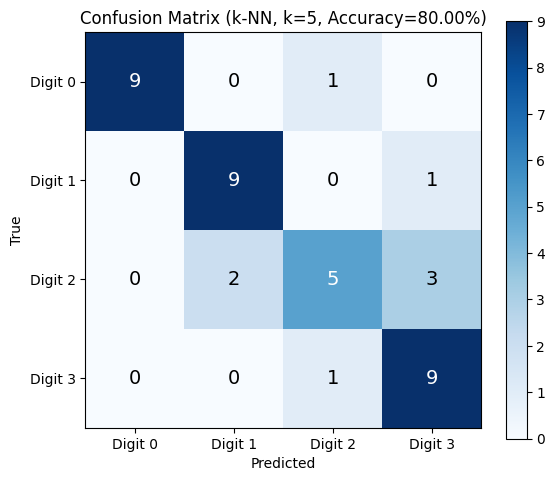


Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      0.90      0.95        10
     Digit 1       0.82      0.90      0.86        10
     Digit 2       0.71      0.50      0.59        10
     Digit 3       0.69      0.90      0.78        10

    accuracy                           0.80        40
   macro avg       0.81      0.80      0.79        40
weighted avg       0.81      0.80      0.79        40



In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

predictions = np.array(predictions)
cm = confusion_matrix(y_eval, predictions, labels=CLASSES)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels([f'Digit {c}' for c in CLASSES])
ax.set_yticklabels([f'Digit {c}' for c in CLASSES])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (k-NN, k={K}, Accuracy={accuracy:.2%})')

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_eval, predictions, target_names=[f'Digit {c}' for c in CLASSES]))

## 6. Discussion

### How the Trainable Parameters Learn Quantum Representations

The parameterized quantum circuit acts as a **quantum feature map**: it transforms classical image features into quantum states in a $2^4 = 16$-dimensional Hilbert space. The trainable parameters shape this mapping so that:

- **Same-class images** $\rightarrow$ nearby states (high fidelity $|\langle\psi|\phi\rangle|^2 \approx 1$)
- **Different-class images** $\rightarrow$ orthogonal states (low fidelity $|\langle\psi|\phi\rangle|^2 \approx 0$)

This is the quantum analog of classical metric learning, where an embedding network learns to map similar inputs close together and dissimilar inputs far apart.

**Role of each parameter group:**
- **Scaling parameters** ($s_i$): Control how much each PCA feature influences the quantum state. The circuit learns which features are most discriminative.
- **$R_Y$ layer**: Adds class-dependent rotations, creating separation in the computational basis.
- **$R_Z$ layer**: Introduces relative phases between basis states, exploiting the full complex Hilbert space.
- **CNOT entanglement**: Creates correlations between qubits, allowing the circuit to capture feature interactions that single-qubit rotations cannot.

### Connection to Quantum Resource Theory

The **SWAP test** is a fundamental primitive in quantum information with deep connections to quantum resource theory:

1. **State comparison without tomography**: The SWAP test estimates $|\langle\psi|\phi\rangle|^2$ using only $O(1)$ measurements per estimate (in expectation), whereas full state tomography requires $O(d^2)$ measurements for $d$-dimensional states. This makes it resource-efficient for comparing quantum encodings.

2. **Benchmarking quantum encodings**: In quantum machine learning, different encoding strategies (angle encoding, amplitude encoding, IQP circuits) map classical data differently into Hilbert space. The SWAP test provides a principled way to evaluate whether an encoding preserves relevant structure. If the encoding is good for a classification task, same-class fidelities should be high.

3. **Quantum advantage in representation**: The Hilbert space dimension grows exponentially with qubit count ($2^n$), potentially allowing quantum encodings to capture complex data relationships in fewer physical resources than classical embeddings of the same dimension. Whether this translates to practical advantage depends on the data structure and the expressiveness of the quantum circuit.

4. **Trainable quantum kernels**: Our framework is closely related to **quantum kernel methods**, where the fidelity $|\langle\psi(x)|\phi(x')\rangle|^2$ serves as a kernel function. The contrastive training optimizes this kernel to be task-specific, rather than using a fixed quantum feature map.

### Limitations and Future Directions

- **Scalability**: The SWAP test requires doubling the number of qubits (plus ancilla). For larger feature spaces, techniques like destructive SWAP tests or randomized measurements could reduce qubit overhead.
- **Barren plateaus**: Deep parameterized circuits can suffer from vanishing gradients. Our shallow (2-layer) architecture mitigates this but limits expressiveness.
- **Classical simulation cost**: Simulating 9 qubits is tractable, but the exponential cost of classical simulation means this approach is best suited for actual quantum hardware at scale.
- **Data encoding bottleneck**: PCA to 4 features loses information. Amplitude encoding could use all 784 features with $\lceil\log_2(784)\rceil = 10$ qubits, but requires more complex state preparation circuits.

In [ ]:
# Final summary
print("=" * 60)
print("Task VI: Quantum Representation Learning — Summary")
print("=" * 60)
print(f"\nDataset: MNIST digits {CLASSES}, {SAMPLES_PER_CLASS} per class")
print(f"Preprocessing: PCA 784 → {N_COMPONENTS} features")
print(f"Quantum circuit: {N_TOTAL_QUBITS} qubits (2×{N_QUBITS} registers + 1 ancilla)")
print(f"Trainable parameters: {N_PARAMS}")
print(f"Training: {N_ITERATIONS} iterations, batch size {BATCH_SIZE}")
print(f"\nFinal metrics (test set):")
print(f"  Same-class fidelity:  {np.mean(eval_fidelities_same):.4f} ± {np.std(eval_fidelities_same):.4f}")
print(f"  Diff-class fidelity:  {np.mean(eval_fidelities_diff):.4f} ± {np.std(eval_fidelities_diff):.4f}")
print(f"  Fidelity gap:         {np.mean(eval_fidelities_same) - np.mean(eval_fidelities_diff):.4f}")
print(f"  k-NN accuracy:        {accuracy:.2%} (random baseline: {1/len(CLASSES):.2%})")
print(f"\nLearned parameters: {params.detach().numpy().round(3)}")

Task VI: Quantum Representation Learning — Summary

Dataset: MNIST digits [0, 1, 2, 3], 500 per class
Preprocessing: PCA 784 → 4 features
Quantum circuit: 9 qubits (2×4 registers + 1 ancilla)
Trainable parameters: 12
Training: 80 iterations, batch size 12

Final metrics (test set):
  Same-class fidelity:  0.7913 ± 0.2364
  Diff-class fidelity:  0.4068 ± 0.2884
  Fidelity gap:         0.3845
  k-NN accuracy:        80.00% (random baseline: 25.00%)

Learned parameters: [1.909 0.465 0.848 0.037 0.291 0.099 0.025 0.054 0.262 0.379 0.167 0.19 ]
